# NSL-KDD: Load and Inspect the Datasets

This notebook only **loads** and **inspects** the two NSL-KDD files.
It does not train a model, encode columns, scale values, or combine train and test.

## 1. Import pandas

`pandas` is the library we use to load CSV-style files into tables called DataFrames.

In [20]:
import pandas as pd

## 2. Define the 43 NSL-KDD column names

The `.txt` files have **no header row**. If we load them without names, pandas would call the columns `0, 1, 2, ...`.

NSL-KDD has **41 predictive features**, plus **`label`** and **`difficulty`**, for **43 columns** in total.

`label` and `difficulty` are **not** model inputs. We name them here only so we can inspect the files correctly.

In [21]:
COLUMNS = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty",
]

## 3. Load KDDTrain+ and KDDTest+

Paths are relative to this notebook (`notebooks/`), so we go up one folder (`..`) into the project root, then into `data/raw/`.

- `header=None` tells pandas: the first line is **data**, not column names.
- `names=COLUMNS` applies the 43 names we defined above.

Train and test are loaded into **separate** DataFrames. We do not combine them.

In [22]:
train_path = "../data/raw/KDDTrain+.txt"
test_path = "../data/raw/KDDTest+.txt"

train_df = pd.read_csv(train_path, header=None, names=COLUMNS)
test_df = pd.read_csv(test_path, header=None, names=COLUMNS)

## 4. Shape of each dataset

`shape` returns `(number of rows, number of columns)`.
Each row is one connection record. Both files should have 43 columns.

In [23]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (125973, 43)
Test shape: (22544, 43)


## 5. First 5 rows of each dataset

`head()` shows the first few rows so we can check that values line up with the column names (for example `protocol_type` should look like `tcp`/`udp`/`icmp`, and `label` like `normal` or an attack name).

In [24]:
print("Train — first 5 rows:")
display(train_df.head())

print("Test — first 5 rows:")
display(test_df.head())

Train — first 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Test — first 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


## 6. Column names

Confirm that pandas stored all 43 names in the expected order.

In [25]:
print("Number of columns:", len(train_df.columns))
print(train_df.columns.tolist())

Number of columns: 43
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']


## 7. Data types

`dtypes` shows how pandas interpreted each column:

- numbers become `int64` or `float64`
- text (such as `protocol_type`, `service`, `flag`, `label`) becomes `object`

We only look at this now. We do not encode categorical columns yet.

In [26]:
print("Train dtypes:")
print(train_df.dtypes)
print()
print("Test dtypes:")
print(test_df.dtypes)

Train dtypes:
duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_

## 8. Missing values

`isna()` marks missing cells. `.sum()` counts them per column.
NSL-KDD is usually complete (zeros, not blanks), but we still check both files.

In [27]:
print("Missing values in train (total):", train_df.isna().sum().sum())
print(train_df.isna().sum())
print()
print("Missing values in test (total):", test_df.isna().sum().sum())
print(test_df.isna().sum())

Missing values in train (total): 0
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv

## 9. Target labels and class imbalance

The `label` column is the **target**: it says whether a connection is `normal` or a named attack.

NSL-KDD uses many specific attack names. For this project we group them into five high-level classes:

- **Normal** — legitimate traffic
- **DoS** — Denial of Service (flood / crash the target)
- **Probe** — scanning and reconnaissance
- **R2L** — Remote-to-Local (break in from the network without an account)
- **U2R** — User-to-Root (a local user tries to become root / admin)

`attack_category` is a **new derived column** in memory only. We do not change the raw `.txt` files, and we still keep train and test separate.

## 9.1 Unique values in the training `label` column

`.unique()` lists every distinct attack name (and `normal`) that appears in KDDTrain+.

In [28]:
print("Unique training labels:")
print(sorted(train_df["label"].unique()))
print()
print("Number of unique training labels:", train_df["label"].nunique())

Unique training labels:
['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'spy', 'teardrop', 'warezclient', 'warezmaster']

Number of unique training labels: 23


## 9.2 Count of each individual training label

`value_counts()` counts how many rows have each label. The most common labels appear first.

In [29]:
train_label_counts = train_df["label"].value_counts()
print("Training label counts:")
display(train_label_counts)

Training label counts:


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

## 9.3 Percentage of each individual training label

`normalize=True` turns counts into proportions. Multiplying by 100 gives a percentage of the training set.

In [30]:
train_label_pct = train_df["label"].value_counts(normalize=True) * 100
print("Training label percentages:")
display(train_label_pct.round(4))

Training label percentages:


label
normal             53.4583
neptune            32.7165
satan               2.8840
ipsweep             2.8570
portsweep           2.3267
smurf               2.1005
nmap                1.1852
back                0.7589
teardrop            0.7081
warezclient         0.7065
pod                 0.1596
guess_passwd        0.0421
buffer_overflow     0.0238
warezmaster         0.0159
land                0.0143
imap                0.0087
rootkit             0.0079
loadmodule          0.0071
ftp_write           0.0064
multihop            0.0056
phf                 0.0032
perl                0.0024
spy                 0.0016
Name: proportion, dtype: float64

## 9.4 Map individual attack names to five categories

The dictionary below is the standard NSL-KDD 5-class grouping.

- Training has 23 labels (including `normal`).
- The test set also contains **extra attack names** that never appear in training. Those names are included here so test rows still get a category.

`.map()` looks up each row's `label` and writes the matching category into a new column `attack_category`.

In [31]:
attack_category_map = {
    # Normal
    "normal": "Normal",
    # DoS — flood or crash the service
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "apache2": "DoS",
    "udpstorm": "DoS",
    "processtable": "DoS",
    "mailbomb": "DoS",
    "worm": "DoS",
    # Probe — scan / reconnaissance
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    # R2L — remote attacker tries to gain local access
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    # U2R — local user tries to become root
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}

train_df["attack_category"] = train_df["label"].map(attack_category_map)
test_df["attack_category"] = test_df["label"].map(attack_category_map)

print("Unmapped training labels:", train_df.loc[train_df["attack_category"].isna(), "label"].unique())
print("Unmapped test labels:", test_df.loc[test_df["attack_category"].isna(), "label"].unique())

Unmapped training labels: []
Unmapped test labels: []


## 9.5 Training distribution of `attack_category`

After grouping, we count how common each of the five classes is in KDDTrain+. This is where class imbalance becomes obvious.

In [32]:
category_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

train_category_counts = train_df["attack_category"].value_counts().reindex(category_order)
train_category_pct = (
    train_df["attack_category"].value_counts(normalize=True).reindex(category_order) * 100
)

train_category_summary = pd.DataFrame(
    {
        "count": train_category_counts,
        "percentage": train_category_pct.round(4),
    }
)
print("Training attack_category distribution:")
display(train_category_summary)

Training attack_category distribution:


,count,percentage
attack_category,,
Normal,67343,53.4583
DoS,45927,36.4578
Probe,11656,9.2528
R2L,995,0.7899
U2R,52,0.0413


## 9.6 Test distribution of `attack_category`

We inspect the test set **separately**. Its mix of attacks is different from training (including some attack names that never appear in KDDTrain+).

In [33]:
test_category_counts = test_df["attack_category"].value_counts().reindex(category_order)
test_category_pct = (
    test_df["attack_category"].value_counts(normalize=True).reindex(category_order) * 100
)

test_category_summary = pd.DataFrame(
    {
        "count": test_category_counts,
        "percentage": test_category_pct.round(4),
    }
)
print("Test attack_category distribution:")
display(test_category_summary)

Test attack_category distribution:


,count,percentage
attack_category,,
Normal,9711,43.0758
DoS,7460,33.0908
Probe,2421,10.7390
R2L,2885,12.7972
U2R,67,0.2972


## 9.7 Bar chart of the training five-class distribution

A bar chart makes the imbalance easier to see than a table: Normal and DoS dominate; R2L and U2R are rare.

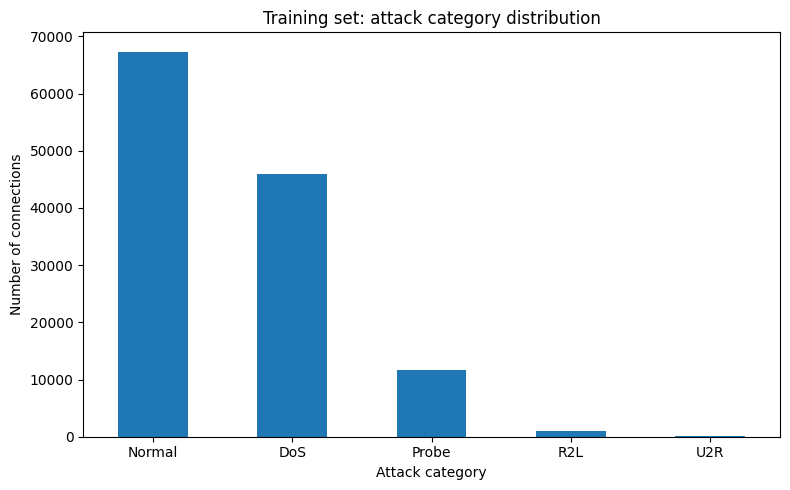

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
train_category_counts.plot(kind="bar")
plt.title("Training set: attack category distribution")
plt.xlabel("Attack category")
plt.ylabel("Number of connections")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. The 41 predictive features

A supervised model needs two things:

- **X** — input features (what the model is allowed to see)
- **y** — the target (what the model should predict)

From each row we keep only the **41 NSL-KDD traffic features**. We drop:

- `label` — the original attack name (target information)
- `difficulty` — dataset metadata, not traffic
- `attack_category` — our five-class target; it belongs in **y**, not in **X**

We still do **not** encode, scale, or train anything in this section.

## 10.1 Create `feature_columns`, then X and y

`COLUMNS` already lists all 43 file columns. The last two are `label` and `difficulty`, so the first 41 names are the predictive features.

`X_train` / `X_test` are tables of those 41 columns.
`y_train` / `y_test` are the five-class `attack_category` values. Train and test stay separate.

In [35]:
feature_columns = [col for col in COLUMNS if col not in ["label", "difficulty"]]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]
y_train = train_df["attack_category"]
y_test = test_df["attack_category"]

print("Number of feature columns:", len(feature_columns))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()
print("Feature names:")
print(feature_columns)

Number of feature columns: 41
X_train shape: (125973, 41)
X_test shape: (22544, 41)
y_train shape: (125973,)
y_test shape: (22544,)

Feature names:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 10.2 Separate categorical and numerical features

NSL-KDD has **3 categorical (text) features**:

- `protocol_type` — e.g. `tcp`, `udp`, `icmp`
- `service` — e.g. `http`, `ftp`, `private`
- `flag` — connection status, e.g. `SF`, `S0`, `REJ`

The other **38** features are numerical (counts, rates, byte sizes, and 0/1 flags such as `logged_in`).

`select_dtypes` asks pandas which columns are text (`object`) vs numbers. We inspect them here only. We do **not** encode or scale yet.

In [36]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(include="number").columns.tolist()

print("Number of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)
print()
print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

Number of categorical features: 3
Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features: 38
Numerical features:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


## 10.3 Descriptive statistics for numerical features

`describe()` summarizes each numeric column: count, mean, standard deviation, min, quartiles, and max.

Look for columns on very different scales (for example bytes in the millions vs rates between 0 and 1). That difference is why Logistic Regression often uses `StandardScaler` later. We only **look** at the numbers now; we do not fit a scaler.

In [37]:
print("Numerical feature summary (training set):")
display(X_train[numerical_features].describe().T)

Numerical feature summary (training set):


,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


## 10.4 Unique values in each categorical feature

`nunique()` counts how many distinct categories each text column has.

- `protocol_type` and `flag` have only a few values.
- `service` has many values (dozens of network services).

Later, an encoder such as `OneHotEncoder` will turn these strings into numbers. We do **not** fit that encoder in this notebook.

In [38]:
print("Number of unique values per categorical feature (training set):")
print(X_train[categorical_features].nunique())
print()
print("Unique protocol_type values:", sorted(X_train["protocol_type"].unique()))
print("Unique flag values:", sorted(X_train["flag"].unique()))
print("Number of unique service values:", X_train["service"].nunique())

Number of unique values per categorical feature (training set):
protocol_type     3
service          70
flag             11
dtype: int64

Unique protocol_type values: ['icmp', 'tcp', 'udp']
Unique flag values: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']
Number of unique service values: 70


## 11. Final Day 1 sanity checks

This last EDA pass only **inspects** the training features we already created.

- We look for numeric columns that never change (zero variance).
- We list every category in `protocol_type`, `service`, and `flag`.
- We do **not** drop columns, encode, scale, or train a model.

## 11.1 Zero-variance numerical features (training set)

A column has **zero variance** when every training row has the same number. Then `std()` is `0`.

Such a column carries no information for training (it cannot help separate classes). We only **identify** it here. We do not remove it in this notebook.

In [ ]:
numeric_std = X_train[numerical_features].std()
zero_variance_features = numeric_std[numeric_std == 0].index.tolist()

print("Zero-variance numerical features:")
print(zero_variance_features)
print()

if len(zero_variance_features) == 0:
    print("No numerical feature has standard deviation 0.")
else:
    print("Standard deviation of each zero-variance feature:")
    print(numeric_std[zero_variance_features])
    print()
    print("Unique values of each zero-variance feature:")
    for col in zero_variance_features:
        print(f"  {col}: {X_train[col].unique()}")

## 11.2 Unique values of each categorical feature

Print every distinct category in the training set, and how many there are.

`service` has many values, so the list is long. That is expected.

In [ ]:
for col in ["protocol_type", "service", "flag"]:
    uniques = sorted(X_train[col].unique())
    print(f"{col}: {len(uniques)} unique values")
    print(uniques)
    print()

## 11.3 Day 1 EDA summary

Main findings from KDDTrain+ and KDDTest+ (no model trained):

- **No missing values.** Both files are complete; zeros are real measurements, not blanks.
- **Severe class imbalance.** Training is mostly **Normal (~53%)** and **DoS (~36%)**. **Probe** is about **9%**. **R2L** is under **1%**. **U2R** is tiny (**52** rows, ~**0.04%**). Accuracy alone would be misleading.
- **Categorical features exist.** Three text columns: `protocol_type` (**3** values), `flag` (**11** values), `service` (**70** values). They cannot go into Logistic Regression as strings; they will need encoding later.
- **Numerical features have very different scales.** Byte counts can be huge; many rate features stay between 0 and 1. That is why Logistic Regression may need scaling later. Tree models generally do not.
- **Some numerical features are highly skewed.** A few columns (for example `src_bytes`, `dst_bytes`, and rare 0/1 flags) have a long tail: most values are small or zero, with rare very large values.
- **One zero-variance feature.** In training, **`num_outbound_cmds`** is always `0`, so its standard deviation is `0`. It adds no training signal. We leave it in place for now.
- **Train and test class mixes differ.** Test has fewer Normal rows (~**43%**) and far more **R2L** (~**13%** vs ~**0.8%** in train). Test also includes attack names that never appear in training. Keep the files **separate**.

**What we will not do yet:** encode, scale, drop columns, build a `Pipeline`, or train a model.